# monocell walkthrough

This notebook runs the bundled sample campaign through the pipeline. Instrument
exports are read into one schema, checked as they are written, and stored.
The store then derives a parameter file for the cell, and PyBaMM runs it.

The data is synthetic, for a 5 Ah NMC811/graphite cell; `lab_exports/INGEST.md`
lists the files. The parameter-extraction step is abstracted in this copy and
returns published PyBaMM `Chen2020` values. The simulation at the end therefore
shows the hand-off to PyBaMM; it is not a model fitted to this data.

Run it from `examples/`. It writes a scratch store to `walkthrough_store/` and
clears it at the start of each run.

In [1]:
import json
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 60)

EXPORTS = Path("lab_exports")
STORE = Path("walkthrough_store")
shutil.rmtree(STORE, ignore_errors=True)

## 1. Register the cell

A build record needs two fields, `capacity_Ah` and `chemistry`; the rest are
optional. The capacity turns currents into C-rates, and it is the reference a
capacity check-up is compared with when the file does not name one.

In [2]:
from monocell.cells import load_build, register_cell

register_cell("demo", {"capacity_Ah": 5.0, "chemistry": "NMC811/graphite"}, STORE)
load_build("demo", STORE)

{'capacity_Ah': 5.0,
 'chemistry': 'NMC811/graphite',
 'registered_at': '2026-09-23T04:52:32.958008+00:00'}

## 2. Look at a file before ingesting it

`probe_file` reports three things about an export and writes nothing: the
instrument profile its headers match, the experiment type its shape suggests
(with the evidence as a sentence), and the columns the reader would not place.
A proposal is never applied automatically.

In [3]:
from monocell.schema.shapes import probe_file

rpt_file = EXPORTS / "cycler" / "landt_rpt_0000efc.csv"
print(pd.read_csv(rpt_file, nrows=3).to_string(index=False))

probe = probe_file(rpt_file, root=STORE, capacity_Ah=5.0)
print("\nprofile:", probe["profile"])
for proposal in probe["types"]:
    print("type:   ", proposal.exp_type, "-", proposal.evidence)

 TestTime/h  Current/mA  Voltage/V  Capacity/mAh  AuxTemp/dC.  Cycle-Index Step-State
    0.00000       250.0   4.120760       0.00000         25.0            1      rated
    0.04004       250.0   4.118341      10.01002         25.0            1      rated
    0.08008       250.0   4.115783      20.02004         25.0            1      rated

profile: landt
type:    rpt - full charge/discharge legs, 1 distinct cycle_index value(s), at C/20. One slow charge/discharge pair is the check-up an RPT is.


The Landt profile converts `TestTime/h` to seconds and `Current/mA` to amperes.
Without it, a reader that took the current column as amperes would be wrong by
a factor of 1000, and nothing in the result would show it.

## 3. Ingest

A folder ingest reads the sidecar JSON beside each file, proposes each file's
type from its shape and prints the plan; `--confirm` writes it. The EIS export
(Palmsense4, UTF-16) and the pressure-rig export have their own readers and are
ingested one at a time. The pressure file is held back until section 9.

In [4]:
from monocell.cli import main as monocell

exit_code = monocell(["ingest", "--cell", "demo", "--dir", str(EXPORTS / "cycler"),
                      "--data-root", str(STORE), "--confirm"])

plan for 11 file(s) in lab_exports\cycler, into cell demo:
  gitt       gitt_15C.csv via the synonym reader — 69621 rows, sidecar gitt_15C.sidecar.json
  hppc       hppc_soc_sweep.csv via the synonym reader — 21000 rows, sidecar hppc_soc_sweep.sidecar.json
  rpt        landt_rpt_0000efc.csv via landt — 1000 rows, sidecar landt_rpt_0000efc.sidecar.json
  rpt        landt_rpt_0200efc.csv via landt — 1000 rows, sidecar landt_rpt_0200efc.sidecar.json
  rpt        landt_rpt_0400efc.csv via landt — 1000 rows, sidecar landt_rpt_0400efc.sidecar.json
  rpt        landt_rpt_0600efc.csv via landt — 1000 rows, sidecar landt_rpt_0600efc.sidecar.json
  rpt        landt_rpt_0800efc.csv via landt — 1000 rows, sidecar landt_rpt_0800efc.sidecar.json
  rpt        landt_rpt_1000efc.csv via landt — 1000 rows, sidecar landt_rpt_1000efc.sidecar.json
  three_electrode_ts three_electrode_0p5C.csv via the synonym reader — 5178 rows, sidecar three_electrode_0p5C.sidecar.json
  three_electrode_ts three_electrode_

In [5]:
from monocell.schema.ingest import ingest

eis_dir = ingest("demo", "eis", EXPORTS / "eis" / "eis_fresh.csv",
                 EXPORTS / "eis" / "eis_fresh.sidecar.json", STORE)
eis_dir

WindowsPath('walkthrough_store/experiments/demo/eis_demo_20260923T045234161352Z')

## 4. What the store holds

Each experiment is a directory: the series as Parquet, `meta.json` (protocol,
instrument, cell state and a quality summary), `quality.json` (the full quality
record) and the raw table as it arrived. Nothing in it is edited after it is
written. The DuckDB manifest is an index over those files and can be rebuilt
from them.

In [6]:
from monocell.schema.manifest import list_experiments

experiments = pd.DataFrame(list_experiments("demo", None, STORE))
experiments[["experiment_id", "exp_type", "created_at"]]

,experiment_id,exp_type,created_at
0,gitt_demo_20260923T045233558532Z,gitt,2026-09-23T04:52:33.558550+00:00
1,hppc_demo_20260923T045233668666Z,hppc,2026-09-23T04:52:33.668684+00:00
2,rpt_demo_20260923T045233723464Z,rpt,2026-09-23T04:52:33.723481+00:00
3,rpt_demo_20260923T045233780159Z,rpt,2026-09-23T04:52:33.780175+00:00
4,rpt_demo_20260923T045233829856Z,rpt,2026-09-23T04:52:33.829875+00:00
5,rpt_demo_20260923T045233877605Z,rpt,2026-09-23T04:52:33.877619+00:00
6,rpt_demo_20260923T045233927102Z,rpt,2026-09-23T04:52:33.927143+00:00
7,rpt_demo_20260923T045233975577Z,rpt,2026-09-23T04:52:33.975592+00:00
8,three_electrode_ts_demo_20260923T045234022988Z,three_electrode_ts,2026-09-23T04:52:34.023004+00:00
9,three_electrode_ts_demo_20260923T045234072991Z,three_electrode_ts,2026-09-23T04:52:34.073007+00:00


Every type has one declared spec: its columns, the instrument metadata it must
carry, the checks run at ingest and the rules that turn missing protocol facts
into flags. The three-electrode spec:

In [7]:
from monocell.schema.tables import SPECS

spec = SPECS["three_electrode_ts"]
print("checks:", spec.quality_checks)
print("rules: ", spec.rules)
pd.DataFrame([(c.name, c.dtype, c.required) for c in spec.columns],
             columns=["column", "dtype", "required"])

checks: ('sum_check',)
rules:  ('soc_basis_recorded', 'capacity_ref_not_nameplate_when_aged')


,column,dtype,required
0,t_s,float64,True
1,I_A,float64,True
2,V_full_V,float64,True
3,V_pos_V,float64,True
4,V_neg_V,float64,True
5,sum_residual_mV,float64,True
6,T_degC,float64,True
7,soc,float64,True
8,seg_id,int32,True
9,seg_type,str,True


In [8]:
from monocell.schema.write_experiment import load_experiment

three_e = sorted(e for e in experiments.experiment_id if e.startswith("three_electrode"))
exp = load_experiment(three_e[0], "demo", STORE)
print(json.dumps({k: exp["meta"][k] for k in ("protocol", "instrument", "cell_state", "quality")},
                 indent=2))
exp["series"].head()

{
  "protocol": {
    "description": "three-electrode charge at 0.5C from 20% SOC, 25 C, stopped when the negative electrode reaches 0 V vs Li",
    "steps": [
      {
        "kind": "charge",
        "c_rate": 0.5
      }
    ]
  },
  "instrument": {
    "name": "potentiostat-02",
    "reference_type": "Li metal",
    "calibrated_at": "2026-01-15",
    "rinse_protocol": "solvent rinse, 3 times",
    "sampling_rate_Hz": 1.0
  },
  "cell_state": {
    "capacity_ref_Ah": 5.0,
    "rpt_index": 0,
    "age_efc": 0.0,
    "soc_basis": "generator_map",
    "capacity_ref_source": "sidecar"
  },
  "quality": {
    "sum_check_ok": true,
    "sum_residual_max_mV": 1.8617369676388051,
    "reference_drift_mV": 0.01831060228035851,
    "kk_ok": null,
    "kk_residual_pct": null,
    "capacity_SOH": null,
    "resistance_SOH_Ohm": null,
    "flags": []
  }
}


,t_s,I_A,V_pos_V,V_neg_V,T_degC,soc,seg_type,V_full_V,sum_residual_mV,seg_id
0,0.0,-2.5,3.721874,0.151707,25.000000,0.200000,anode_hold,3.571041,0.874780,0
1,1.0,-2.5,3.722468,0.150231,25.002213,0.200139,anode_hold,3.571947,-0.290248,0
2,2.0,-2.5,3.722257,0.150085,25.004441,0.200278,anode_hold,3.572501,0.328337,0
3,3.0,-2.5,3.722672,0.150366,25.006684,0.200417,anode_hold,3.572673,0.367353,0
4,4.0,-2.5,3.723094,0.149620,25.008940,0.200556,anode_hold,3.573970,0.495518,0


## 5. Checks at ingest

Each file is checked as it is written, and the results are stored with it:

- a three-electrode run must satisfy V_full = V_pos - V_neg; the largest
  residual and the drift of the reference electrode are recorded;
- an EIS spectrum is tested with a linear Kramers-Kronig fit, and a residual
  above 1% is flagged;
- a check-up's discharge capacity is compared with the cell's reference
  capacity (a state of health);
- ingest rules flag missing or doubtful protocol facts, such as an RPT faster
  than C/20 or an HPPC without a recorded rest rule.

In [9]:
from monocell.schema.write_experiment import load_meta

rows = []
for rec in list_experiments("demo", None, STORE):
    meta = load_meta(rec["experiment_id"], "demo", STORE)
    q = meta["quality"]
    rows.append({"type": rec["exp_type"], "age_efc": meta["cell_state"].get("age_efc"),
                 "capacity_SOH": q["capacity_SOH"], "sum_residual_max_mV": q["sum_residual_max_mV"],
                 "kk_residual_pct": q["kk_residual_pct"], "flags": len(q["flags"])})
quality = pd.DataFrame(rows)
quality.round(4)

,type,age_efc,capacity_SOH,sum_residual_max_mV,kk_residual_pct,flags
0,gitt,0.0,NaN,NaN,NaN,0
1,hppc,0.0,NaN,NaN,NaN,1
2,rpt,0.0,0.9990,NaN,NaN,0
3,rpt,200.0,0.8902,NaN,NaN,0
4,rpt,400.0,0.8147,NaN,NaN,0
5,rpt,600.0,0.7562,NaN,NaN,0
6,rpt,800.0,0.6997,NaN,NaN,0
7,rpt,1000.0,0.6305,NaN,NaN,0
8,three_electrode_ts,0.0,NaN,1.8617,NaN,0
9,three_electrode_ts,0.0,NaN,1.9016,NaN,0


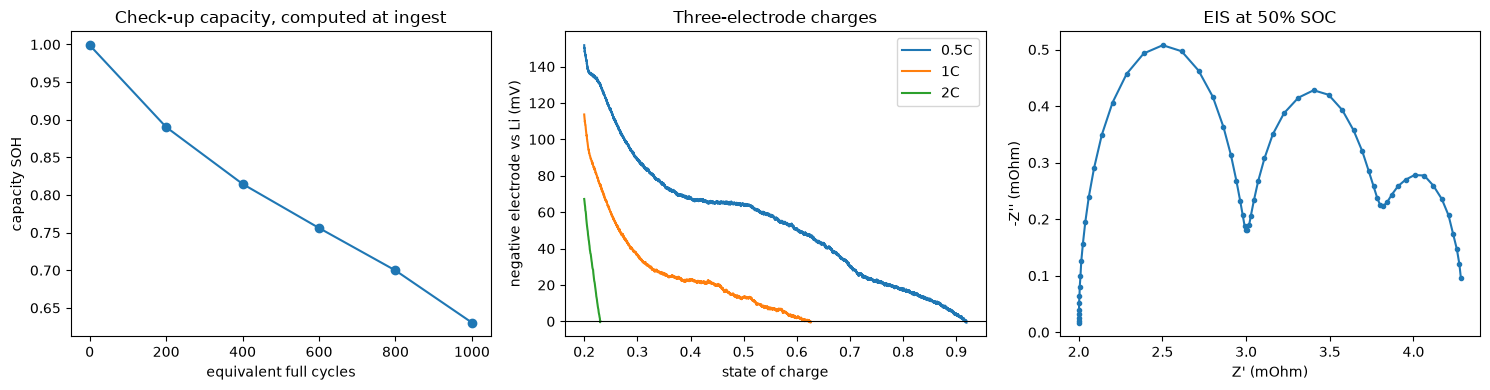

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rpt = quality[quality.type == "rpt"].sort_values("age_efc")
axes[0].plot(rpt.age_efc, rpt.capacity_SOH, "o-")
axes[0].set(xlabel="equivalent full cycles", ylabel="capacity SOH",
            title="Check-up capacity, computed at ingest")

for eid in three_e:
    e = load_experiment(eid, "demo", STORE)
    rate = e["meta"]["protocol"]["steps"][0]["c_rate"]
    axes[1].plot(e["series"].soc, e["series"].V_neg_V * 1000, label=f"{rate:g}C")
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set(xlabel="state of charge", ylabel="negative electrode vs Li (mV)",
            title="Three-electrode charges")
axes[1].legend()

z = load_experiment(eis_dir.name, "demo", STORE)["series"]
axes[2].plot(z.Z_re_Ohm * 1000, -z.Z_im_Ohm * 1000, ".-")
axes[2].set(xlabel="Z' (mOhm)", ylabel="-Z'' (mOhm)", title="EIS at 50% SOC")
fig.tight_layout()

## 6. Search

`search_experiments` filters the manifest in SQL (cell, type, date window,
lot), then reads the flags from each result's own `meta.json`. The one flag in
this campaign is informational: the HPPC file has no reference electrode, so
the three-electrode sum check does not apply to it.

In [11]:
from monocell.schema.manifest import search_experiments

for r in search_experiments(STORE, flagged=True):
    print(r["exp_type"], r["experiment_id"])
    for flag in r["flags"]:
        print("   ", flag)

hppc hppc_demo_20260923T045233668666Z
    no reference electrode columns — sum-check skipped


## 7. Derive the parameter file

`rederive` compares each derived artifact with the experiments it was made
from, by content hash, and re-runs whatever is stale. The graph here has one
module, the parameter extraction.

**That step is abstracted in this copy.** It returns fixed `Chen2020` values
whatever the data says. The code around it is the real code: loading the
inputs, citing each one by hash, versioning the file and tracking staleness.

In [12]:
from monocell.rederive import list_stale, rederive

for row in list_stale("demo", STORE):
    print(row["module"], "-", row["reason"])
done = rederive("demo", STORE)
parameter_file = Path(done[0]["artifact"])
parameter_file.name

parameters - 12 experiment(s) without a current parameters artifact


'parameter_file_demo_v27ba7f.json'

In [13]:
from monocell.schema.artifacts import load_artifact

envelope = load_artifact(parameter_file)
print(len(envelope["inputs"]), "inputs, each cited with its content hash:")
print(json.dumps(envelope["inputs"][:2], indent=2))
record = envelope["data"]
print("\nbase set:", record["base_parameter_set"], "| source:", record["source"])
print(record["note"])
pd.Series(record["pybamm_overrides"], name="value").to_frame()

12 inputs, each cited with its content hash:
[
  {
    "id": "eis_demo_20260923T045234161352Z",
    "hash": "6bfc19f735d1857570bb5a07616d051bd2222104930d85fc5d2a45bc17f3fa61"
  },
  {
    "id": "gitt_demo_20260923T045233558532Z",
    "hash": "808748bef1ae01d28bb29a1c11a2038cd1bb39db9340b8e0e4b05b07920f0b49"
  }
]

base set: Chen2020 | source: abstracted
Parameter extraction is abstracted in this copy. These are published Chen2020 values and do not depend on the cell's data.


,value
Nominal cell capacity [A.h],5.000000
Lower voltage cut-off [V],2.500000
Upper voltage cut-off [V],4.200000
Electrode height [m],0.065000
Electrode width [m],1.580000
Negative electrode thickness [m],0.000085
Separator thickness [m],0.000012
Positive electrode thickness [m],0.000076
Negative electrode porosity,0.250000
Separator porosity,0.470000


## 8. Run it through PyBaMM

`simulate` loads the named base set, applies the file's overrides (a key the
base set does not define is refused) and runs a constant-current discharge from
full charge to the lower cut-off. Each run is written as an artifact that cites
the parameter file's hash.

0.5C: 5.1 Ah, 18.27 Wh, 122 min
1C: 5.0 Ah, 17.50 Wh, 60 min
2C: 4.8 Ah, 15.87 Wh, 29 min


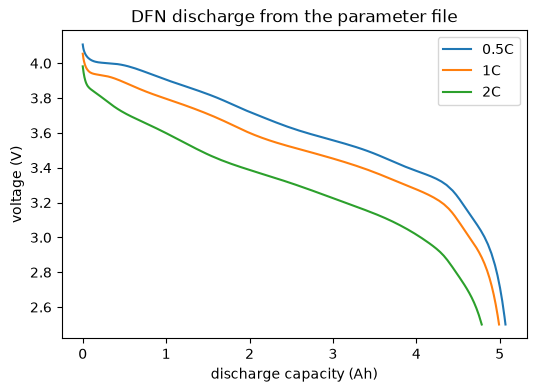

In [14]:
from monocell.simulate import simulate

fig, ax = plt.subplots(figsize=(6, 4))
for c_rate in (0.5, 1.0, 2.0):
    result = simulate("demo", c_rate=c_rate, model="DFN", root=STORE)
    s = result["summary"]
    print(f"{c_rate:g}C: {s['capacity_Ah']:.1f} Ah, {s['energy_Wh']:.2f} Wh, "
          f"{s['duration_s'] / 60:.0f} min")
    ax.plot(result["curve"]["Q_Ah"], result["curve"]["V_V"], label=f"{c_rate:g}C")
ax.set(xlabel="discharge capacity (Ah)", ylabel="voltage (V)",
       title="DFN discharge from the parameter file")
ax.legend();

## 9. New data makes the parameter file stale

The pressure test arrives. The parameter file cites every experiment the cell
had when it was written, so it is now behind. Re-deriving writes a new version
and keeps the previous one.

In [15]:
ingest("demo", "pressure", EXPORTS / "pressure" / "pressure_cycle.csv",
       EXPORTS / "pressure" / "pressure_cycle.sidecar.json", STORE)

for row in list_stale("demo", STORE):
    print(row["module"], "-", row["reason"])

rederive("demo", STORE)
sorted(p.name for p in (STORE / "artifacts" / "demo" / "parameters").glob("*.json"))

parameters - 1 experiment(s) without a current parameters artifact


['parameter_file_demo_v1b00d6.json', 'parameter_file_demo_v27ba7f.json']

## 10. Withdrawing an experiment

An experiment ingested by mistake is retracted with a reason. Its files stay
on disk, derivations stop using it, and anything derived from it goes stale.

In [16]:
from monocell.schema.write_experiment import retract

wrong = sorted(e for e in experiments.experiment_id if e.startswith("rpt"))[-1]
retract(wrong, "demo", "the sidecar named the wrong channel", STORE)

for row in list_stale("demo", STORE):
    print(row["module"], "-", row["reason"])
print("files still on disk:", (STORE / "experiments" / "demo" / wrong / "series.parquet").exists())

parameters - 1 consumed experiment(s) are no longer current (retracted or removed): rpt_demo_20260923T045233975577Z
files still on disk: True
